--- RAW DATASET SAVED AS 'housing.csv' ---
Original Shape: (20640, 10)


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY



--- Missing Values Check ---
total_bedrooms    207
dtype: int64


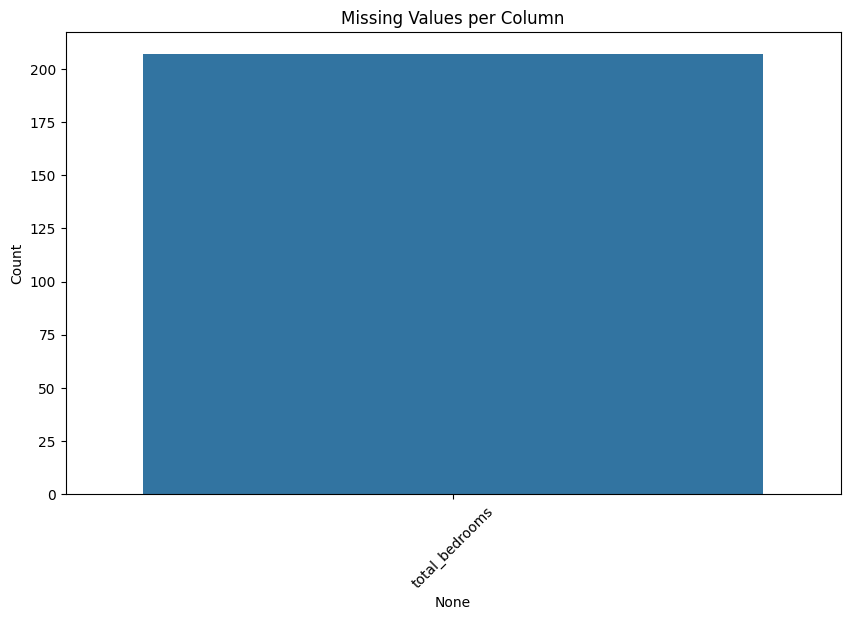


Imputed 'total_bedrooms' with median: 435.0

--- Validation After Cleaning ---
Total Missing Values Remaining: 0

SUCCESS: 'cleaned_dataset.csv' has been saved.
You now have both 'housing.csv' and 'cleaned_dataset.csv' in your file folder.


/tmp/ipython-input-2286974853.py:38: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['total_bedrooms'].fillna(median_val, inplace=True)


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load Dataset
url = "https://raw.githubusercontent.com/ageron/handson-ml2/master/datasets/housing/housing.csv"
df = pd.read_csv(url)

# Save the raw file locally so you can upload it to GitHub later
df.to_csv("housing.csv", index=False)
print("--- RAW DATASET SAVED AS 'housing.csv' ---")

print(f"Original Shape: {df.shape}")
display(df.head())

# 2. Identify Missing Values
print("\n--- Missing Values Check ---")
missing = df.isnull().sum()
missing = missing[missing > 0]
print(missing)

# 3. Visualize Missing Data
if not missing.empty:
    plt.figure(figsize=(10, 6))
    sns.barplot(x=missing.index, y=missing.values)
    plt.xticks(rotation=45)
    plt.title("Missing Values per Column")
    plt.ylabel("Count")
    plt.show()
else:
    print("No missing values to visualize.")

# 4. Data Cleaning (Imputation)
# Filling missing 'total_bedrooms' with the Median value
if 'total_bedrooms' in df.columns:
    median_val = df['total_bedrooms'].median()
    df['total_bedrooms'].fillna(median_val, inplace=True)
    print(f"\nImputed 'total_bedrooms' with median: {median_val}")

# 5. Validate Dataset
print("\n--- Validation After Cleaning ---")
remaining_missing = df.isnull().sum().sum()
print(f"Total Missing Values Remaining: {remaining_missing}")

# 6. Save Cleaned Dataset
df.to_csv("cleaned_dataset.csv", index=False)
print("\nSUCCESS: 'cleaned_dataset.csv' has been saved.")
print("You now have both 'housing.csv' and 'cleaned_dataset.csv' in your file folder.")